## GET 324 Group CO8 - Healthy Tomato vs Tomato Yellow Leaf Curl Virus

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## *Data Loading*

In [3]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Base path to your Tomato folder in Drive
base_path = '/content/drive/My Drive/Tomato'

# Define image size and batch size
img_size = (256, 256)
batch_size = 32

# Create data generators with preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_path, "Train"),
    target_size=img_size,
    batch_size=batch_size,
    classes={'Healthy': 0, 'Yellow Leaf Curl Virus': 1},
    class_mode='binary'
)

# Load validation data
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_path, "Val"),
    target_size=img_size,
    batch_size=batch_size,
    classes={'Healthy': 0, 'Yellow Leaf Curl Virus': 1},
    class_mode='binary'
)

# Load test data
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_path, "Test"),
    target_size=img_size,
    batch_size=batch_size,
    classes={'Healthy': 0, 'Yellow Leaf Curl Virus': 1},
    class_mode='binary'
)

print("Data loaded successfully!")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 3887 images belonging to 2 classes.
Found 873 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Data loaded successfully!
Training samples: 3887
Validation samples: 873
Test samples: 98


## *Model Building (transfer learning)*

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pre-trained MobileNetV2
base_model = MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')

# Freeze the base model
base_model.trainable = False

# Build our model on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_1805/3141314523.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## *Model Training*

In [5]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    verbose=1
)

Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 798s 7s/step - accuracy: 0.9768 - loss: 0.0619 - val_accuracy: 0.9931 - val_loss: 0.0135
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 0.9964 - loss: 0.0117 - val_accuracy: 0.9989 - val_loss: 0.0069
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.9969 - loss: 0.0114 - val_accuracy: 0.9989 - val_loss: 0.0038
Epoch 4/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 376s 3s/step - accuracy: 0.9987 - loss: 0.0061 - val_accuracy: 0.9977 - val_loss: 0.0050
Epoch 5/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 373s 3s/step - accuracy: 0.9995 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0030


## *Test Evaluation*

In [6]:
# Test the model on completely unseen data
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 1.0000 - loss: 0.0022

Test Loss: 0.0022
Test Accuracy: 1.0000


## *Confusion Matrix + Metrics*

Found 98 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


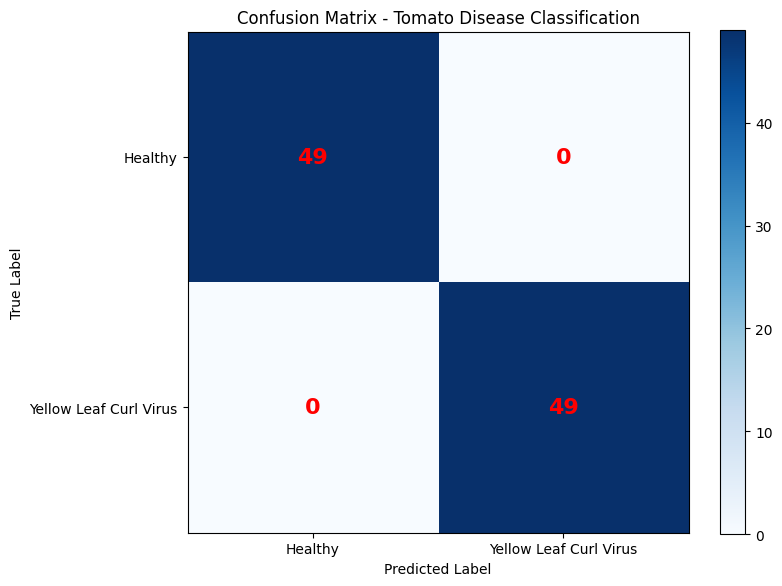

In [12]:
# Get Test Predictions

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# RELOAD test generator with shuffle=False (CRITICAL!)
test_generator_correct = val_test_datagen.flow_from_directory(
    '/content/drive/My Drive/Tomato/Test',
    target_size=(256, 256),
    batch_size=1,  # Process one image at a time for perfect alignment
    classes={'Healthy': 0, 'Yellow Leaf Curl Virus': 1},
    class_mode='binary',
    shuffle=False  # THIS IS THE KEY
)

# Get predictions in correct order
all_predictions = []
all_true_labels = []

for i in range(test_generator_correct.samples):
    batch = next(test_generator_correct)
    pred = model.predict(batch[0])
    all_predictions.append(pred[0][0])
    all_true_labels.append(batch[1][0])

test_pred_classes = (np.array(all_predictions) > 0.5).astype(int)
test_true_labels = np.array(all_true_labels).astype(int)

# Confusion Matrix
cm = confusion_matrix(test_true_labels, test_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(test_true_labels, test_pred_classes,
                          target_names=['Healthy', 'Yellow Leaf Curl Virus']))

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Tomato Disease Classification')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['Healthy', 'Yellow Leaf Curl Virus'])
plt.yticks([0, 1], ['Healthy', 'Yellow Leaf Curl Virus'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='red', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## *Saving The Model*

In [14]:
# Save the model for later deployment with Streamlit

save_path_keras = '/content/drive/My Drive/tomato_disease_model.keras'
model.save(save_path_keras)
print(f"Model saved to: {save_path_keras}")

Model saved to: /content/drive/My Drive/tomato_disease_model.keras
